### Preprocessing and augmentations ###

In [55]:
import sys
import os
import numpy as np
import pandas as pd
import glob
import copy
import tarfile
from pathlib import Path
from matplotlib import pyplot as plt
import albumentations as alb

# Appearance of the Notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Import this module with autoreload
%load_ext autoreload
%autoreload 2

import computervision as cv
from computervision.fileutils import FileOP
from computervision.imageproc import ImageData, is_image
from computervision.transformations import AugmentationTransform

# Print version info
print(f'Package version: {cv.__version__}')
print(f'Authors:         {cv.__authors__}')
print(f'Python version:  {sys.version}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Package version: v0.0.2
Authors:         The Core for Computational Biomedicine at Harvard Medical School
https://dbmi.hms.harvard.edu/about-dbmi/core-computational-biomedicine
Python version:  3.12.3 (main, Jun 18 2025, 17:59:45) [GCC 13.3.0]


In [35]:
data_dir = os.environ.get('DATA_DIR')
print(f'data_dir: {data_dir}')
# Directory to store the dentex data set
dataset_name = 'dataset_dental_roboflow'
dataset_dir = os.path.join(data_dir, 'roboflow')
image_dir = os.path.join(dataset_dir, dataset_name, 'cropped')

data_dir: /app/data


In [36]:
# Open the annotation file (in the image directory after extraction)
annotations_file_name = 'annotations_cropped_dset.parquet'
annotations_file = os.path.join(image_dir, annotations_file_name)
df = pd.read_parquet(annotations_file)
display(df.head(2))
print(df.shape)

file_col = 'file_name'
bbox_col= 'bbox'
label_col = 'label'

# Check the images
file_list = [os.path.join(image_dir, file_name) for file_name in df[file_col].unique()]
checked = [is_image(file) for file in file_list]
assert len(file_list) == sum(checked), f'WARNING: Could not open all {len(file_list)} images at: {image_dir}'
print(f'Image directory:        {image_dir}')
print(f'Total number of images: {len(file_list)}')
print(f'Annotations:            {df.shape[0]}')

,multi_file,file_name,width,height,area,label,bbox,pos,pos_bbox,dset
0,a0ab0bec5c.jpg,tooth_02_a0ab0bec5c.jpg,152,236,35872,tooth,None,[2],None,train
1,5c6869fdf0.jpg,amalgam_03_5c6869fdf0.jpg,427,265,113155,amalgam,"[182, 29, 119, 112]","[19, 20]","[[143, 20, 284, 245], [20, 33, 382, 232]]",train


(7550, 10)
Image directory:        /app/data/roboflow/dataset_dental_roboflow/cropped
Total number of images: 7550
Annotations:            7550


In [37]:
# Image numbers
label_list = sorted(list(df[label_col].unique()))

for dset in ['train', 'val', 'test']:
    df_dset = df.loc[(df['dset'] == dset)]
    print()
    print(f'{len(df_dset[file_col].unique())} total images in dataset {dset.upper()}')
    n_label = df_dset[[label_col, file_col]].\
        groupby(label_col).\
        nunique().\
        reset_index(drop=False).\
        rename(columns={file_col: 'n_images'}).\
        sort_values(by='n_images', ascending=False).\
        reset_index(drop=True)
    display(n_label)


7190 total images in dataset TRAIN


,label,n_images
0,tooth,3902
1,composite,1426
2,amalgam,600
3,Calculus,567
4,caries,518
5,root filling,177



180 total images in dataset VAL


,label,n_images
0,Calculus,30
1,amalgam,30
2,caries,30
3,composite,30
4,root filling,30
5,tooth,30



180 total images in dataset TEST


,label,n_images
0,Calculus,30
1,amalgam,30
2,caries,30
3,composite,30
4,root filling,30
5,tooth,30


In [38]:
# Summary statistics for the different labels
label_list = list(df[label_col].unique())
stat_col = 'width'
for label in label_list:
    print()
    print(f'{label.upper()} COLUMN "{stat_col}"')
    df_label = df.loc[df[label_col] == label]
    display(df_label[stat_col].describe())


TOOTH COLUMN "width"


count    3962.000000
mean      226.802373
std        88.996351
min       100.000000
25%       152.000000
50%       212.000000
75%       288.750000
max       459.000000
Name: width, dtype: float64


AMALGAM COLUMN "width"


count    660.000000
mean     445.419697
std      113.096174
min      103.000000
25%      388.000000
50%      456.500000
75%      527.250000
max      640.000000
Name: width, dtype: float64


CARIES COLUMN "width"


...

count    1486.000000
mean      444.956258
std       116.474856
min       102.000000
25%       386.000000
50%       461.000000
75%       529.000000
max       640.000000
Name: width, dtype: float64


CALCULUS COLUMN "width"


count    627.000000
mean     438.076555
std      106.374064
min      111.000000
25%      381.500000
50%      447.000000
75%      515.000000
max      640.000000
Name: width, dtype: float64


ROOT FILLING COLUMN "width"


count    237.000000
mean     440.265823
std      106.778724
min      145.000000
25%      391.000000
50%      453.000000
75%      528.000000
max      640.000000
Name: width, dtype: float64

### Preprocessing of the images ###
All of the images have different sizes. For the model we need all images to be the same shape. It is not always a good idea to change the aspect ratio of the images. This is the process:

1. Determine the largest image dimension S in the data set
3. Scale all smaller images (with original aspect ration maintained) so that their largest dimension is S
4. Pad the smaller dimension to obtain square images for the model input
5. Scale the square image to the input size of the model

In [68]:
display(df.head(2))
max_width = df['width'].max()
max_height = df['height'].max()
print(f'Maximum image dimensions in the data set (width/height): {max_width}/{max_height}')

# We are going to scale all images to the maximum dimension of all images
# Then we pad all images to make them square
# For the model input, these images will then be scaled to the correct input size

max_size = max((max_width, max_height))
print(f'Maximum image size: {max_size}')

# Instantiate the Transform class for this operation
transforms = AugmentationTransform(max_size=max_size).\
                get_transforms(name='resize_and_pad')
T = alb.Compose(transforms)

,multi_file,file_name,width,height,area,label,bbox,pos,pos_bbox,dset
0,a0ab0bec5c.jpg,tooth_02_a0ab0bec5c.jpg,152,236,35872,tooth,None,[2],None,train
1,5c6869fdf0.jpg,amalgam_03_5c6869fdf0.jpg,427,265,113155,amalgam,"[182, 29, 119, 112]","[19, 20]","[[143, 20, 284, 245], [20, 33, 382, 232]]",train


Maximum image dimensions in the data set (width/height): 640/480
Maximum image size: 640


,multi_file,file_name,width,height,area,label,bbox,pos,pos_bbox,dset
6846,aa95608f74.jpg,tooth_05_aa95608f74.jpg,116,224,25984,tooth,None,[5],None,train


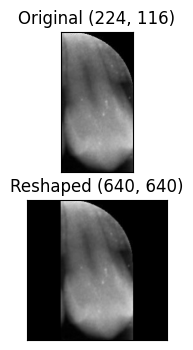

In [133]:
tooth_files = df.loc[df[label_col] == 'tooth', file_col].tolist()
np.random.seed(234)
file_name_list = np.random.choice(tooth_files, size=20, replace=False)

for f, file_name in enumerate(file_name_list[3:4]):
    
    df_file = df.loc[df[file_col] == file_name]
    file = os.path.join(image_dir, file_name)
    im = ImageData().load_image(file)
    im_output = T(image=im)['image']
    
    display(df_file)
    
    fig, ax = plt.subplots(nrows=2, ncols=1, figsize = (2, 4))
    ax[0].imshow(im)
    ax[0].set_title(f'Original {im.shape[:2]}')
    ax[1].imshow(im_output)
    ax[1].set_title(f'Reshaped {im_output.shape[:2]}')
    for axa in ax:
        axa.set(xticks=[], yticks=[])
    
    plt.show()

### Image augmentations ###

In [134]:
def load_and_process_image(image_file_path, max_image_size=550):
    transforms = AugmentationTransform(max_size=max_image_size).\
                get_transforms(name='resize_and_pad')
    T = alb.Compose(transforms)
    im_raw = ImageData().load_image(image_file_path)
    im_output = T(image=im_raw)['image']
    return im_output

In [136]:
# Let's assume, the input size to the model is 512 pixels
im_size = 512
# Here is a list of example augmentations
# A complete list of pixel-level transformations is here
# https://github.com/albumentations-team/albumentations#pixel-level-transforms
train_aug = alb.Compose([
    alb.Resize(im_size + 32, im_size + 32),
    alb.RandomCrop(im_size, im_size),
    alb.HorizontalFlip(),
    alb.Affine(scale=(0.9, 1.1), 
               translate_percent=(-0.0625, 0.0625), 
               rotate=(-45, 45), 
               keep_ratio=True, p=1),
    alb.Blur(),
    alb.RandomGamma(),
    alb.Sharpen(),
    alb.GaussNoise(),
    alb.CoarseDropout(num_holes_range=(1, 16),
                      hole_height_range=(4, 32),
                      hole_width_range=(4, 32)),
    alb.CLAHE()])
# Set the number of random transformations
n_transforms = 14
n_images = 5

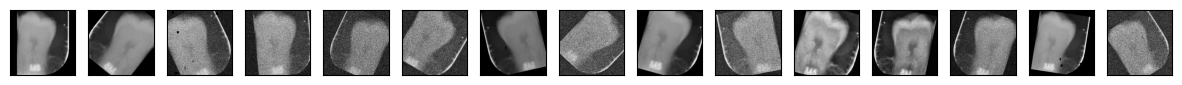

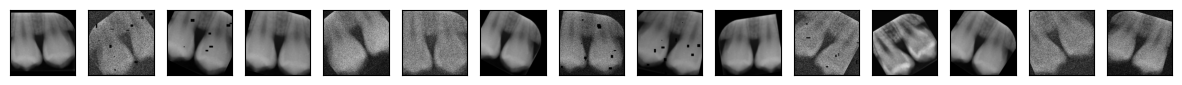

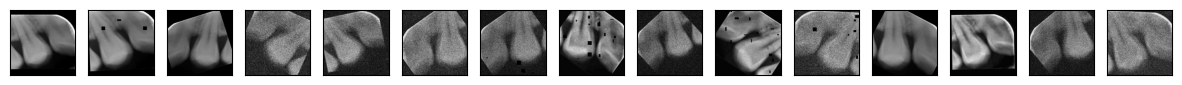

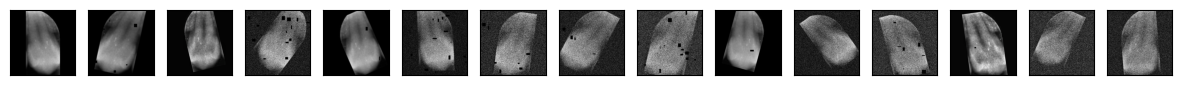

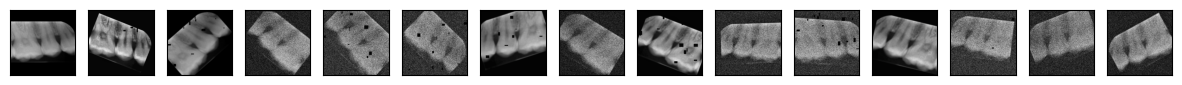

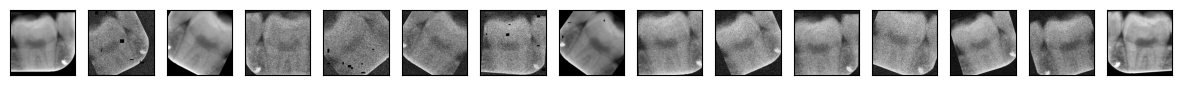

In [137]:
figsize = (15, 15)
for file_name in file_name_list[:6]:
    file = os.path.join(image_dir, file_name)
    im = load_and_process_image(image_file_path=file, max_image_size=max_size)
    fig, ax = plt.subplots(nrows=1, ncols=n_transforms+1, figsize=figsize)
    ax[0].imshow(im)
    ax[0].set(xticks=[], yticks=[])
    for n in range(n_transforms):
        im_aug = train_aug(image=im)['image']
        ax[n + 1].imshow(im_aug)
        ax[n + 1].set(xticks=[], yticks=[])
    plt.show()